Saving student_data.csv to student_data.csv

Logistic Regression Accuracy: 0.9434
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        55
           1       0.96      0.92      0.94        51

    accuracy                           0.94       106
   macro avg       0.94      0.94      0.94       106
weighted avg       0.94      0.94      0.94       106



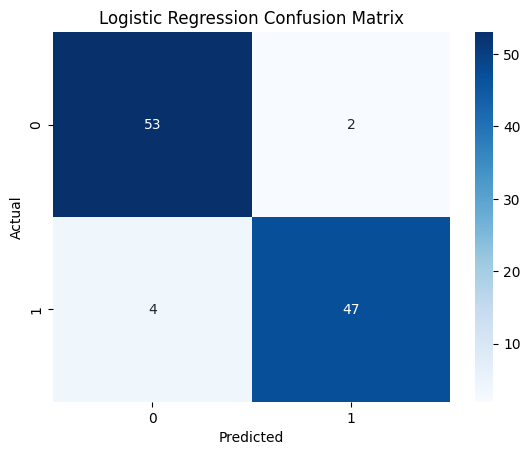


Decision Tree Accuracy: 0.9057
              precision    recall  f1-score   support

           0       0.89      0.93      0.91        55
           1       0.92      0.88      0.90        51

    accuracy                           0.91       106
   macro avg       0.91      0.90      0.91       106
weighted avg       0.91      0.91      0.91       106



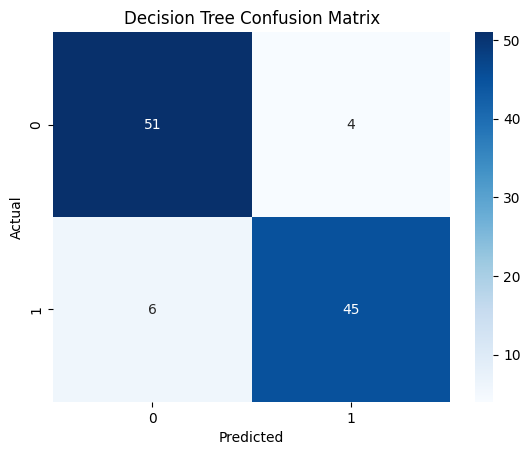


Random Forest Accuracy: 0.9151
              precision    recall  f1-score   support

           0       0.91      0.93      0.92        55
           1       0.92      0.90      0.91        51

    accuracy                           0.92       106
   macro avg       0.92      0.91      0.91       106
weighted avg       0.92      0.92      0.92       106



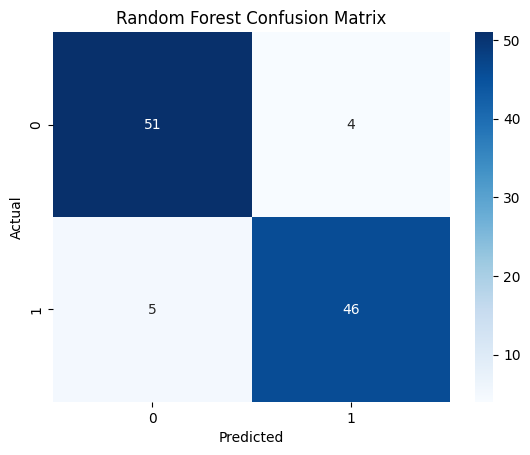

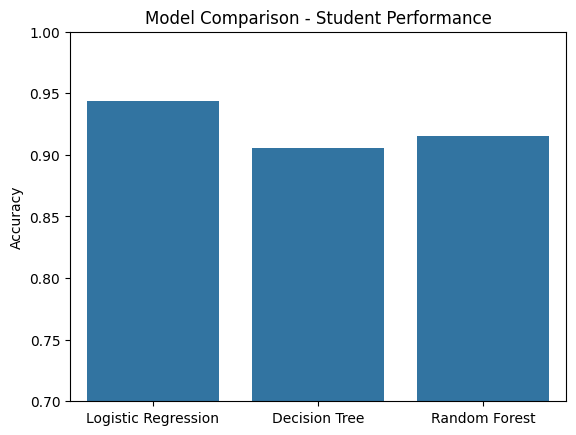

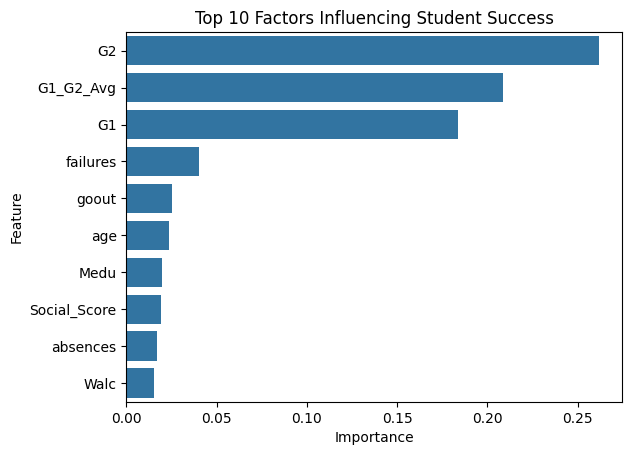

In [ ]:
# --------------------------------------------------
# Import required libraries
# --------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

# --------------------------------------------------
# Load the dataset
# --------------------------------------------------

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("student_data.csv")
df.head()

# --------------------------------------------------
# Create target variable from G3
# --------------------------------------------------
# At-risk: G3 < 10
# Successful: G3 >= 10

df['Outcome'] = np.where(df['G3'] >= 10, 1, 0)

# Drop G3 after creating target
df.drop('G3', axis=1, inplace=True)

# --------------------------------------------------
# Encode categorical variables
# --------------------------------------------------

label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# --------------------------------------------------
# Feature engineering
# --------------------------------------------------

# Academic progression feature
df['G1_G2_Avg'] = (df['G1'] + df['G2']) / 2

# Alcohol impact score
df['Alcohol_Consumption'] = df['Dalc'] + df['Walc']

# Social activity balance
df['Social_Score'] = df['freetime'] + df['goout'] + df['activities']

# --------------------------------------------------
# Define features and target
# --------------------------------------------------

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# --------------------------------------------------
# Scale numerical features
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------
# Handle class imbalance using SMOTE
# --------------------------------------------------

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# --------------------------------------------------
# Train-test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------------
# Hyperparameter tuning
# --------------------------------------------------

# Logistic Regression
log_params = {'C': [0.01, 0.1, 1, 10]}
log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    log_params,
    cv=5
)
log_grid.fit(X_train, y_train)
best_logistic = log_grid.best_estimator_

# Decision Tree
tree_params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    tree_params,
    cv=5
)
tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_

# Random Forest
forest_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    forest_params,
    cv=5
)
forest_grid.fit(X_train, y_train)
best_forest = forest_grid.best_estimator_

# --------------------------------------------------
# Model evaluation function
# --------------------------------------------------

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

# --------------------------------------------------
# Evaluate models
# --------------------------------------------------

acc_log = evaluate_model(best_logistic, "Logistic Regression")
acc_tree = evaluate_model(best_tree, "Decision Tree")
acc_forest = evaluate_model(best_forest, "Random Forest")

# --------------------------------------------------
# Model comparison
# --------------------------------------------------

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [acc_log, acc_tree, acc_forest]

sns.barplot(x=models, y=accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison - Student Performance")
plt.ylim(0.7, 1.0)
plt.show()

# --------------------------------------------------
# Feature importance (Top 10)
# --------------------------------------------------

importances = best_forest.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Top 10 Factors Influencing Student Success")
plt.show()
